In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# 1. Define where your zip file is in Drive
# Hint: If you just uploaded it to the main folder, it's likely here:
zip_path = '/content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip'

# 2. Unzip into a local folder
!unzip "$zip_path" -d "/content/cumida_data"

# 3. Check the file name inside
print("Files found:", os.listdir("/content/cumida_data"))

Archive:  /content/drive/MyDrive/breast-cancer-gene-expression-cumida.zip
  inflating: /content/cumida_data/Breast_GSE45827.csv  
Files found: ['Breast_GSE45827.csv']


In [3]:
import pandas as pd
import glob

# Find the CSV automatically (so exact filename doesn't matter)
csv_files = glob.glob('/content/cumida_data/*.csv')

if csv_files:
    file_path = csv_files[0]
    print(f"Loading: {file_path}")
    df = pd.read_csv(file_path)

    # Quick sanity check
    print(f"Data Shape: {df.shape}") # Should be approx (151, 54678)
    print("Classes:", df['type'].unique())
else:
    print("No CSV found! Check your zip file.")

Loading: /content/cumida_data/Breast_GSE45827.csv
Data Shape: (151, 54677)
Classes: ['basal' 'HER' 'cell_line' 'normal' 'luminal_A' 'luminal_B']


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# 1. Load Data (assuming you unzipped it as discussed)
# Replace with your actual path if different
df = pd.read_csv('/content/cumida_data/Breast_GSE45827.csv')

# 2. Separate Target & Features
# 'type' is usually the target in CuMiDa, 'samples' is metadata
X = df.drop(['samples', 'type'], axis=1)
y = df['type']

# 3. Label Encoding (Target)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"Classes found: {le.classes_}")

# 4. Train/Test Split (Stratified is crucial for small data!)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- BRANCH A: For Traditional & Transformer (Numerical) ---

# Step A1: Feature Selection (Reduce 54k -> 2k genes)
# We only fit this on TRAIN data to avoid data leakage
selector = SelectKBest(score_func=f_classif, k=10000)
selector.fit(X_train_raw, y_train)

# Get the names of the top genes (We need these for the LLM later!)
top_gene_names = X.columns[selector.get_support()]

# Transform the data
X_train_reduced = selector.transform(X_train_raw)
X_test_reduced = selector.transform(X_test_raw)

# Step A2: Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

print(f"Original Shape: {X_train_raw.shape}")
print(f"Processed Shape: {X_train_scaled.shape}")

# --- BRANCH B: For LLM (Text Serialization) ---

def serialize_row(row_values, feature_names):
    """Convert a row of gene values into a text description."""
    text_parts = []
    # We zip the gene names with their values
    for name, val in zip(feature_names, row_values):
        # We can simplify: is it positive (up-regulated) or negative?
        status = "high" if val > 0 else "low"
        text_parts.append(f"{name} is {status}")

    # Join first 50 genes to keep text length manageable for BERT
    return "Breast cancer profile: " + ", ".join(text_parts[:50]) + "."

# Apply to Train data
# Note: We use the REDUCED data so we only serialize important genes
X_train_text = [serialize_row(row, top_gene_names) for row in X_train_reduced]
X_test_text = [serialize_row(row, top_gene_names) for row in X_test_reduced]

print(f"LLM Example Input: {X_train_text[0][:100]}...")

Classes found: ['HER' 'basal' 'cell_line' 'luminal_A' 'luminal_B' 'normal']
Original Shape: (120, 54675)
Processed Shape: (120, 10000)
LLM Example Input: Breast cancer profile: 1053_at is high, 117_at is high, 1487_at is high, 1552263_at is high, 1552264...


🚀 Initializing Autoencoder for 10000 features on cuda...
🚀 Phase 1: Pre-training (Compressing 57k genes)...
   Epoch 10/60 | Reconstruction Loss: 0.4867
   Epoch 20/60 | Reconstruction Loss: 0.4263
   Epoch 30/60 | Reconstruction Loss: 0.3795
   Epoch 40/60 | Reconstruction Loss: 0.3353
   Epoch 50/60 | Reconstruction Loss: 0.2967
   Epoch 60/60 | Reconstruction Loss: 0.2548

🚀 Phase 2: Training Classifier on 128 Latent Features...
   Epoch 10/60 | Classifier Train Acc: 0.9500
   Epoch 20/60 | Classifier Train Acc: 0.9917
   Epoch 30/60 | Classifier Train Acc: 1.0000
   Epoch 40/60 | Classifier Train Acc: 1.0000
   Epoch 50/60 | Classifier Train Acc: 0.9917
   Epoch 60/60 | Classifier Train Acc: 1.0000

✅ Denoising Autoencoder Final Accuracy: 0.9677


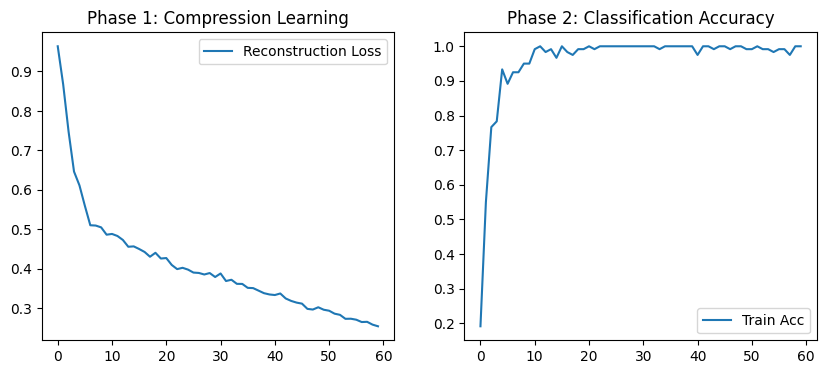

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import copy
import numpy as np

# --- CONFIGURATION ---
# Auto-detect input dim (should be ~57,000)
INPUT_DIM = X_train_scaled.shape[1]
LATENT_DIM = 128                    # Compress 57k -> 128 features (Aggressive compression)
NUM_CLASSES = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Initializing Autoencoder for {INPUT_DIM} features on {device}...")

# --- 1. DEFINE MODELS ---

class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super(Autoencoder, self).__init__()

        # Encoder: 57k -> 4096 -> 1024 -> 128
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(),

            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, latent_dim), # Bottleneck
            nn.ReLU()
        )

        # Decoder: 128 -> 1024 -> 4096 -> 57k
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.ReLU(),

            nn.Linear(1024, 4096),
            nn.ReLU(),

            nn.Linear(4096, input_dim)
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return latent, reconstructed

class ClassifierHead(nn.Module):
    def __init__(self, encoder, latent_dim, num_classes):
        super(ClassifierHead, self).__init__()
        self.encoder = encoder  # Use the pre-trained encoder

        # Freeze the encoder weights?
        # No, we let them fine-tune slightly (better for accuracy)

        self.head = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.4), # High dropout to prevent overfitting on small data
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        latent = self.encoder(x)
        logits = self.head(latent)
        return logits

# --- 2. DATA PREP (Low Memory Mode) ---
# We use .float() explicitly to ensure compatibility
train_tensor_x = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
train_tensor_y = torch.tensor(y_train, dtype=torch.long).to(device)
test_tensor_x = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
test_tensor_y = torch.tensor(y_test, dtype=torch.long).to(device)

train_ds = TensorDataset(train_tensor_x, train_tensor_y)
test_ds = TensorDataset(test_tensor_x, test_tensor_y)

# Small batch size to handle the massive 57k columns
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# --- 3. PHASE 1: UNSUPERVISED PRE-TRAINING ---
print("🚀 Phase 1: Pre-training (Compressing 57k genes)...")
autoencoder = Autoencoder(INPUT_DIM, LATENT_DIM).to(device)
optimizer_ae = optim.Adam(autoencoder.parameters(), lr=1e-4) # Lower LR for stability
criterion_ae = nn.MSELoss()

ae_losses = []

for epoch in range(60):
    autoencoder.train()
    running_loss = 0.0
    for inputs, _ in train_loader:
        # Add Noise: Force model to ignore random gene spikes
        noise = torch.randn_like(inputs) * 0.2
        noisy_inputs = inputs + noise

        optimizer_ae.zero_grad()
        _, reconstructed = autoencoder(noisy_inputs)

        loss = criterion_ae(reconstructed, inputs) # Compare to CLEAN input
        loss.backward()
        optimizer_ae.step()
        running_loss += loss.item()

    ae_losses.append(running_loss / len(train_loader))
    if (epoch+1) % 10 == 0:
        print(f"   Epoch {epoch+1}/60 | Reconstruction Loss: {ae_losses[-1]:.4f}")

# Extract encoder
trained_encoder = copy.deepcopy(autoencoder.encoder)

# --- 4. PHASE 2: SUPERVISED CLASSIFICATION ---
print("\n🚀 Phase 2: Training Classifier on 128 Latent Features...")
model = ClassifierHead(trained_encoder, LATENT_DIM, NUM_CLASSES).to(device)
optimizer_clf = optim.Adam(model.parameters(), lr=1e-4)
criterion_clf = nn.CrossEntropyLoss()

clf_accs = []

for epoch in range(60):
    model.train()
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        optimizer_clf.zero_grad()
        outputs = model(inputs)
        loss = criterion_clf(outputs, labels)
        loss.backward()
        optimizer_clf.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = correct / total
    clf_accs.append(train_acc)

    if (epoch+1) % 10 == 0:
        print(f"   Epoch {epoch+1}/60 | Classifier Train Acc: {train_acc:.4f}")

# --- 5. FINAL EVALUATION ---
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

final_acc = correct / total
print(f"\n✅ Denoising Autoencoder Final Accuracy: {final_acc:.4f}")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(ae_losses, label='Reconstruction Loss')
plt.title('Phase 1: Compression Learning')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(clf_accs, label='Train Acc')
plt.title('Phase 2: Classification Accuracy')
plt.legend()
plt.show()

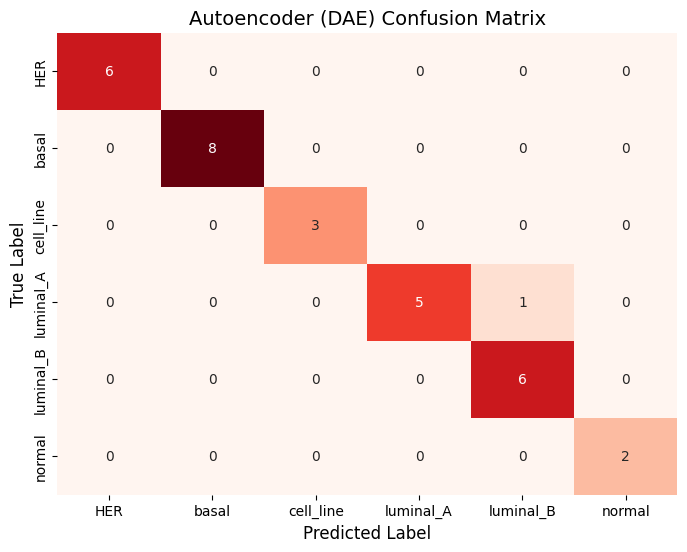

In [6]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Get Predictions from the Autoencoder Classifier
model.eval() # This is your 'ClassifierHead' model
y_pred_dae = []
y_true_dae = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs) # Pass through encoder -> head
        _, predicted = torch.max(outputs, 1)

        y_pred_dae.extend(predicted.cpu().numpy())
        y_true_dae.extend(labels.cpu().numpy())

# 2. Compute Matrix
cm = confusion_matrix(y_true_dae, y_pred_dae)

# 3. Plot (Using 'Reds' for the Experimental model)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Autoencoder (DAE) Confusion Matrix', fontsize=14)
plt.show()

✅ Custom Model Precision & Recall Report:

              precision    recall  f1-score   support

         HER       1.00      1.00      1.00         6
       basal       1.00      1.00      1.00         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       1.00      0.83      0.91         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      1.00      1.00         2

    accuracy                           0.97        31
   macro avg       0.98      0.97      0.97        31
weighted avg       0.97      0.97      0.97        31



/tmp/ipython-input-2835226757.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


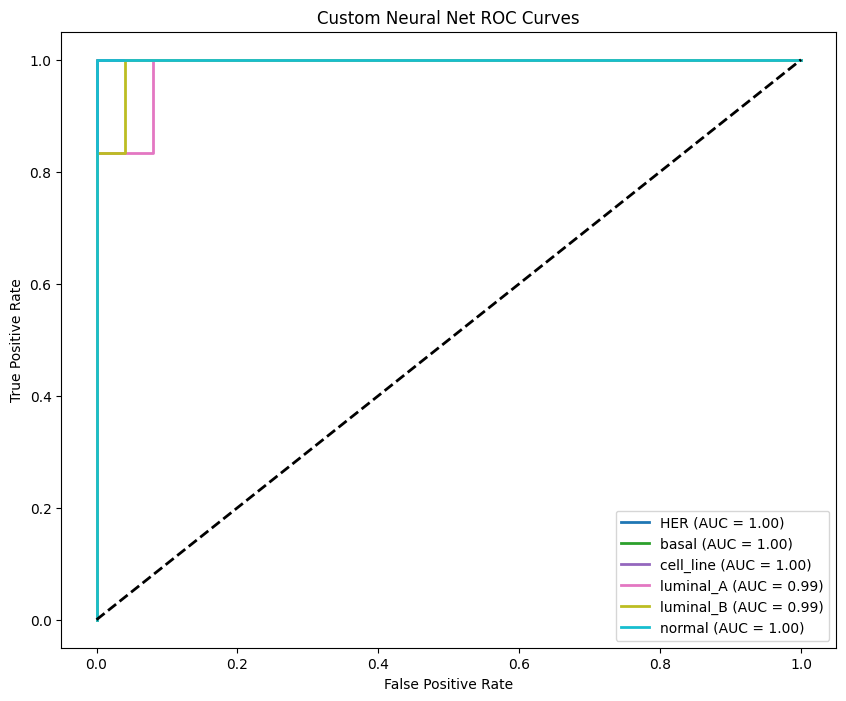

In [9]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Select the model you want to plot (model_custom OR model)
active_model = model  # Change to 'model' for Autoencoder
active_model.eval()

# --- 1. Loop to Gather Probabilities ---
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = active_model(inputs)
        probs = F.softmax(outputs, dim=1) # Softmax for probabilities
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

y_probs = np.concatenate(all_probs)
y_true = np.concatenate(all_labels)

# Binarize
y_test_bin = label_binarize(y_true, classes=np.unique(y_true))
n_classes = y_test_bin.shape[1]
y_pred_class = np.argmax(y_probs, axis=1)

# --- 2. Print Precision/Recall Values ---
print("✅ Custom Model Precision & Recall Report:\n")
# Note: You might need to manually list target_names if 'le' isn't available
print(classification_report(y_true, y_pred_class, target_names=le.classes_))

# --- 3. Plot ROC Curve ---
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors(i), lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Custom Neural Net ROC Curves')
plt.legend(loc="lower right")
plt.show()